# Proyecto Final - Diplomado de Ciencia de Datos (UNAM - DCD12)
## Detección Temprana de Hits en México: de Viral 50 a Top 200
### Autor: Zadkiel David Zerpa Méndez

# Modelos

✅ Librerías importadas correctamente
Cargando audio features...
  Shape: (729, 59)
Cargando Spotify Charts MX...
  Shape: (118804, 10)
Cargando YouTube MX (3 partes)...
  Shape YouTube: (95999, 16)

✅ Datos cargados correctamente

--- Limpieza de Audio Features ---
Columnas originales: 59
⚠️ Columnas duplicadas encontradas. Resolviendo...
  Columnas después de deduplicar: 47

  PASO 2: VARIABLE OBJETIVO
Registros en Viral 50: 23604
Registros en Top 200:  95200
Tracks únicos Viral 50: 1045
Tracks únicos Top 200:  1219

--- Distribución del target (H=28 días) ---
target
0    904
1    141
Name: count, dtype: int64
Tasa de clase positiva: 13.49%

  PASO 3: FEATURES DE SPOTIFY CHARTS
Features de Charts para 1045 tracks (100% cobertura)

  PASO 4: AUDIO FEATURES (matching mejorado)
  ✅ 'popularity' encontrada y agregada como feature extra
Audio features: ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'popularity']

  

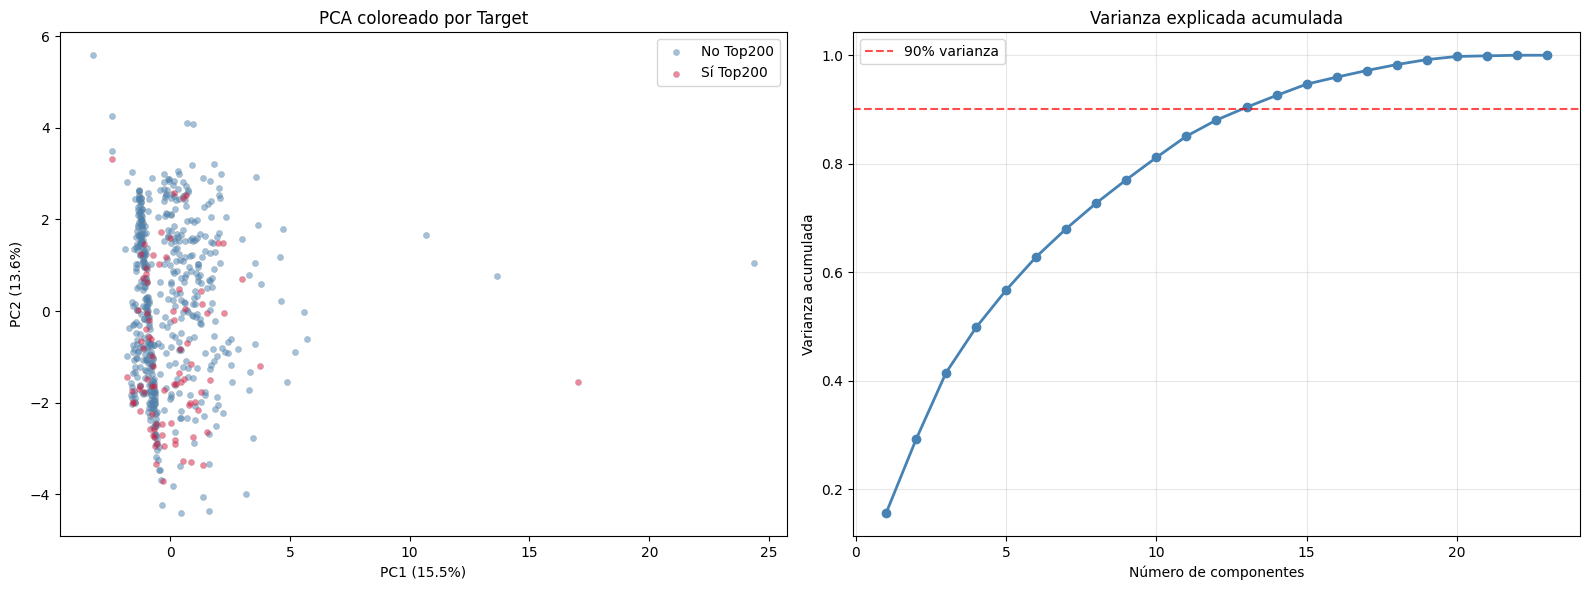

  Componentes para 90% varianza: 13

[K-Means] Clustering sobre features de Charts...
  k=2: Silhouette=0.3716
  k=3: Silhouette=0.4321
  k=4: Silhouette=0.3526
  k=5: Silhouette=0.2954
  k=6: Silhouette=0.3168
  k=7: Silhouette=0.3275
  k=8: Silhouette=0.3073


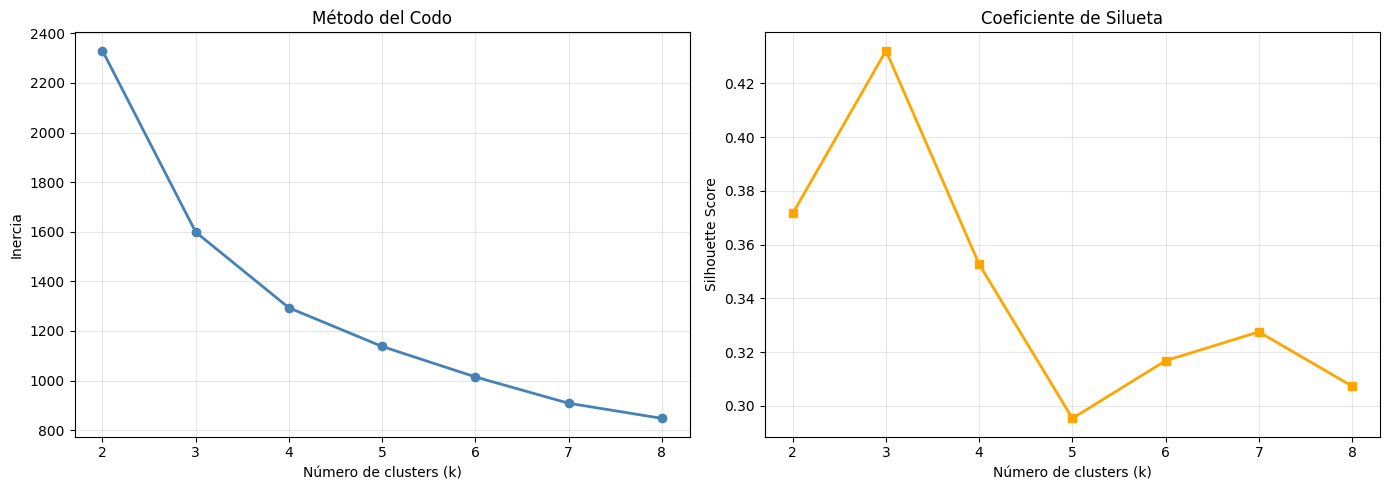

  Mejor k: 3

  Hit rate por cluster (k=3):


,cluster,n_tracks,n_hits,hit_rate
0,0,308,22,7.1
1,1,75,14,18.7
2,2,244,49,20.1



  Perfil promedio por cluster:


,best_rank,worst_rank,mean_rank,days_on_viral,rank_range,rank_slope
cluster,,,,,,
0,35.80,47.10,41.07,10.85,11.30,0.37
1,10.37,20.01,13.73,13.77,9.64,0.12
2,10.05,46.77,23.29,44.08,36.71,0.95


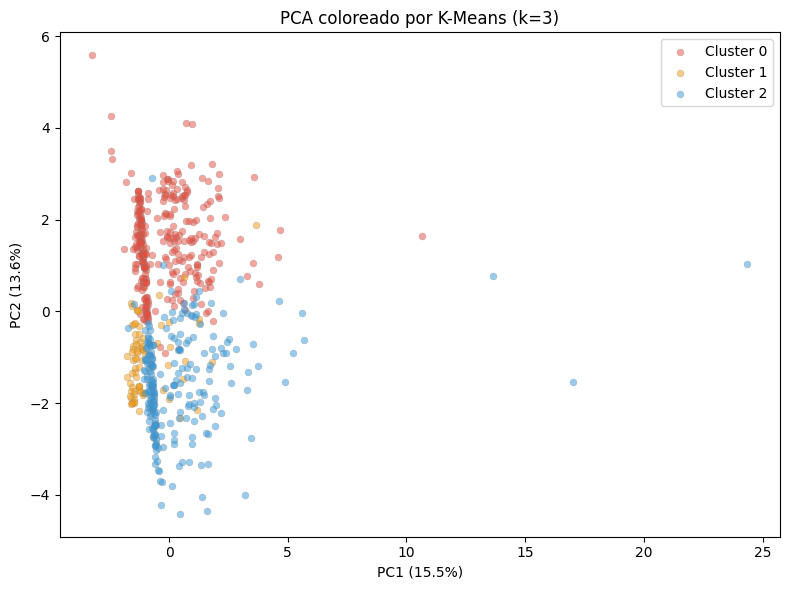

  ✅ K-Means completado

  IMPORTANCIA DE VARIABLES (Random Forest)


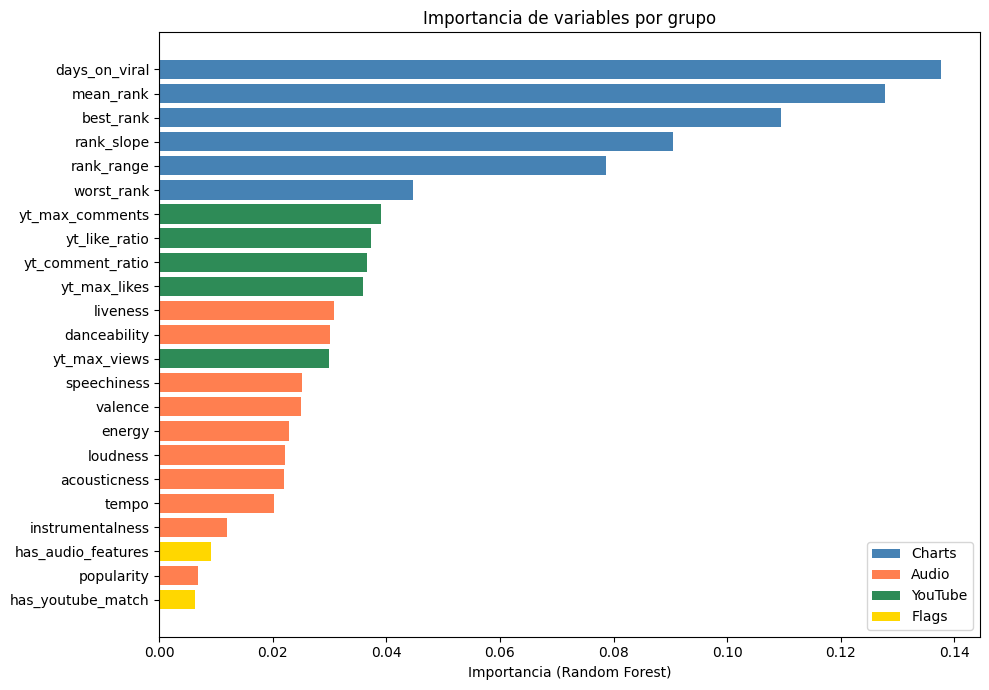


Top 7 variables más importantes:


,feature,importance
3,days_on_viral,0.137672
2,mean_rank,0.127850
0,best_rank,0.109516
5,rank_slope,0.090538
4,rank_range,0.078675
1,worst_rank,0.044666
18,yt_max_comments,0.039058



  RESUMEN - CAPÍTULO 11: MÉTODOS Y MODELOS

Dataset analítico:
  - Total tracks: 1045
  - Features: 23 (6 charts + 10 audio + 5 YouTube + 2 flags)
  - Partición: Train=627 / Val=209 / Test=209
  - Clase 0: 904 | Clase 1: 141 (13.5% positivos)

Cobertura de features:
  - Charts (rank): 100%
  - Audio features: 210 tracks (20.1%)
  - YouTube: 492 tracks (47.1%)
  - Flags binarias: has_audio_features, has_youtube_match

Modelos supervisados:
  1. Regresión Logística (baseline)
  2. Árbol de Decisión (max_depth=5)
  3. Random Forest (n_estimators=200)
  4. Gradient Boosting (n_estimators=200)

Modelos no supervisados:
  - PCA: 29.2% varianza en 2 comp. (13 componentes para 90%)
  - K-Means: k=3 clusters (sobre features de Charts)

📌 Evaluación formal → Capítulo 12



In [1]:
# ============================================================
# PASO 0: Importaciones
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Modelos no supervisados
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Visualización
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

# ============================================================
# PASO 1: Cargar datos desde GitHub (formato Parquet)
# ============================================================

BASE_RAW = "https://raw.githubusercontent.com/ZadkielZ/ds12/main/"

print("Cargando audio features...")
df_feat_union = pd.read_parquet(BASE_RAW + "spotify_audio_features_union_for_mx_window.parquet")
print(f"  Shape: {df_feat_union.shape}")

print("Cargando Spotify Charts MX...")
df_sp = pd.read_parquet(BASE_RAW + "spotify_charts_mx_window_2020-08-12_2021-11-30.parquet")
print(f"  Shape: {df_sp.shape}")

print("Cargando YouTube MX (3 partes)...")
yt_parts = [pd.read_parquet(BASE_RAW + f"youtube_trending_mx_window_2020-08-12_2021-11-30_part{i}.parquet") for i in range(1, 4)]
df_yt = pd.concat(yt_parts, ignore_index=True)
print(f"  Shape YouTube: {df_yt.shape}")

print("\n✅ Datos cargados correctamente")

# ============================================================
# PASO 1.5: Limpieza de columnas de Audio Features
# ============================================================

print("\n--- Limpieza de Audio Features ---")

# Guardar columnas originales para diagnóstico
print(f"Columnas originales: {len(df_feat_union.columns)}")

# Pasar a minúscula
df_feat_union.columns = df_feat_union.columns.str.lower()

# Resolver columnas duplicadas (ej: "Danceability" y "danceability" se repiten)
# Quedarnos con la que tenga MENOS NaN (más datos reales)
if df_feat_union.columns.duplicated().any():
    print("⚠️ Columnas duplicadas encontradas. Resolviendo...")
    cols_seen = {}
    cols_to_drop = []
    for i, col in enumerate(df_feat_union.columns):
        if col in cols_seen:
            existing_idx = cols_seen[col]
            nan_existing = df_feat_union.iloc[:, existing_idx].isna().sum()
            nan_new = df_feat_union.iloc[:, i].isna().sum()
            if nan_new < nan_existing:
                cols_to_drop.append(existing_idx)
                cols_seen[col] = i
            else:
                cols_to_drop.append(i)
        else:
            cols_seen[col] = i
    df_feat_union = df_feat_union.iloc[:, [i for i in range(len(df_feat_union.columns)) if i not in cols_to_drop]]
    print(f"  Columnas después de deduplicar: {len(df_feat_union.columns)}")

# ============================================================
# PASO 2: Construcción de la variable objetivo (target)
# ============================================================

print("\n" + "="*60)
print("  PASO 2: VARIABLE OBJETIVO")
print("="*60)

df_sp["date"] = pd.to_datetime(df_sp["date"], errors="coerce")

df_viral = df_sp[df_sp["chart"].str.lower().str.contains("viral")].copy()
df_top200 = df_sp[df_sp["chart"].str.lower().str.contains("top200|top 200")].copy()

print(f"Registros en Viral 50: {len(df_viral)}")
print(f"Registros en Top 200:  {len(df_top200)}")

viral_first = df_viral.groupby("track_id")["date"].min().reset_index().rename(columns={"date": "first_viral_date"})
top200_first = df_top200.groupby("track_id")["date"].min().reset_index().rename(columns={"date": "first_top200_date"})

print(f"Tracks únicos Viral 50: {len(viral_first)}")
print(f"Tracks únicos Top 200:  {len(top200_first)}")

H = 28
df_target = viral_first.merge(top200_first, on="track_id", how="left")
df_target["days_to_top200"] = (df_target["first_top200_date"] - df_target["first_viral_date"]).dt.days
df_target["target"] = 0
mask_hit = (
    df_target["days_to_top200"].notna() &
    (df_target["days_to_top200"] >= 0) &
    (df_target["days_to_top200"] <= H)
)
df_target.loc[mask_hit, "target"] = 1

print(f"\n--- Distribución del target (H={H} días) ---")
print(df_target["target"].value_counts())
print(f"Tasa de clase positiva: {df_target['target'].mean():.2%}")

# ============================================================
# PASO 3: Features de Spotify Charts (basadas en rank)
# ============================================================

print("\n" + "="*60)
print("  PASO 3: FEATURES DE SPOTIFY CHARTS")
print("="*60)

df_viral_sorted = df_viral.sort_values(["track_id", "date"]).copy()

viral_features = df_viral_sorted.groupby("track_id").agg(
    best_rank      = ("rank", "min"),
    worst_rank     = ("rank", "max"),
    mean_rank      = ("rank", "mean"),
    days_on_viral  = ("date", "nunique"),
).reset_index()

viral_features["rank_range"] = viral_features["worst_rank"] - viral_features["best_rank"]

def calc_rank_slope(group):
    if len(group) < 2:
        return 0.0
    x = np.arange(len(group), dtype=float)
    y = group["rank"].values.astype(float)
    try:
        return np.polyfit(x, y, 1)[0]
    except Exception:
        return 0.0

rank_slopes = df_viral_sorted.groupby("track_id").apply(calc_rank_slope).reset_index(name="rank_slope")
viral_features = viral_features.merge(rank_slopes, on="track_id", how="left")
viral_features["rank_slope"] = viral_features["rank_slope"].fillna(0)

print(f"Features de Charts para {len(viral_features)} tracks (100% cobertura)")

# ============================================================
# PASO 4: Audio Features (MATCHING MEJORADO: track_id + artista/título)
# ============================================================

print("\n" + "="*60)
print("  PASO 4: AUDIO FEATURES (matching mejorado)")
print("="*60)

AUDIO_COLS = [
    "danceability", "energy", "valence", "tempo", "loudness",
    "acousticness", "speechiness", "instrumentalness", "liveness"
]

# Agregar popularity si existe
if "popularity" in df_feat_union.columns:
    AUDIO_COLS.append("popularity")
    print("  ✅ 'popularity' encontrada y agregada como feature extra")

available_audio = [c for c in AUDIO_COLS if c in df_feat_union.columns]
print(f"Audio features: {available_audio}")

# --- Función de limpieza de texto (reutilizable) ---
def clean_text(text):
    """Limpia texto para matching."""
    if pd.isna(text):
        return ""
    t = str(text).lower().strip()
    for tag in ["(official video)", "(video oficial)", "(official music video)",
                "(official audio)", "(audio oficial)", "(lyric video)", "(lyrics)",
                "(letra)", "(visualizer)", "(en vivo)", "(live)", "(audio)",
                "[official video]", "[video oficial]", "[official audio]",
                "official video", "video oficial", "music video",
                "audio oficial", "lyric video", "(official)", "ft.", "feat.",
                "(remix)", "- remix"]:
        t = t.replace(tag, "")
    t = "".join(c if c.isalnum() or c == " " else " " for c in t)
    t = " ".join(t.split())
    return t.strip()

# --- NIVEL 1: Match por track_id ---
df_audio_by_id = df_feat_union[["track_id"] + available_audio].copy()
if df_audio_by_id.columns.duplicated().any():
    df_audio_by_id = df_audio_by_id.loc[:, ~df_audio_by_id.columns.duplicated(keep="first")]
df_audio_by_id["track_id"] = df_audio_by_id["track_id"].astype(str).str.strip()
df_audio_by_id = df_audio_by_id.dropna(subset=available_audio[:9], how="all")
df_audio_by_id = df_audio_by_id.drop_duplicates(subset="track_id", keep="first")

viral_ids = set(viral_features["track_id"].astype(str).str.strip())
match_by_id = viral_ids.intersection(set(df_audio_by_id["track_id"]))
print(f"\n  Nivel 1 (track_id): {len(match_by_id)} matches ({100*len(match_by_id)/len(viral_ids):.1f}%)")

# --- NIVEL 2: Match por artista + título limpio ---
# Preparar tabla de audio features con artist + name para matching
audio_name_cols = []
for col_name in ["artist", "artist_name", "artists"]:
    if col_name in df_feat_union.columns:
        audio_name_cols.append(col_name)
        break
for col_name in ["name", "track_name", "track"]:
    if col_name in df_feat_union.columns:
        audio_name_cols.append(col_name)
        break

print(f"  Columnas para matching por nombre: {audio_name_cols}")

matched_extra = []
if len(audio_name_cols) == 2:
    # Preparar audio features con nombre limpio
    df_audio_names = df_feat_union[["track_id"] + audio_name_cols + available_audio].copy()
    if df_audio_names.columns.duplicated().any():
        df_audio_names = df_audio_names.loc[:, ~df_audio_names.columns.duplicated(keep="first")]
    df_audio_names = df_audio_names.dropna(subset=available_audio[:9], how="all")

    artist_col, name_col = audio_name_cols
    df_audio_names["audio_artist_clean"] = df_audio_names[artist_col].apply(clean_text)
    df_audio_names["audio_name_clean"] = df_audio_names[name_col].apply(clean_text)

    # Preparar tracks virales con nombre limpio
    spotify_info = df_viral[["track_id", "title", "artist"]].drop_duplicates(subset="track_id", keep="first").copy()
    spotify_info["sp_title_clean"] = spotify_info["title"].apply(clean_text)
    spotify_info["sp_artist_clean"] = spotify_info["artist"].apply(clean_text)

    # Solo buscar para tracks que NO matchearon por track_id
    remaining_ids = viral_ids - match_by_id
    remaining_tracks = spotify_info[spotify_info["track_id"].isin(remaining_ids)]

    for _, row in remaining_tracks.iterrows():
        sp_title = row["sp_title_clean"]
        sp_artist = row["sp_artist_clean"]
        if len(sp_title) < 3:
            continue

        # Buscar: título de audio contiene título de Spotify
        mask_title = df_audio_names["audio_name_clean"].str.contains(sp_title, na=False, regex=False)
        candidates = df_audio_names[mask_title]

        if len(candidates) == 0:
            continue

        # Si hay varios, filtrar por artista
        if sp_artist and len(candidates) > 1:
            first_word = sp_artist.split()[0]
            if len(first_word) >= 3:
                mask_artist = candidates["audio_artist_clean"].str.contains(first_word, na=False, regex=False)
                if mask_artist.any():
                    candidates = candidates[mask_artist]

        # Tomar el primero
        best = candidates.iloc[0]
        record = {"track_id": row["track_id"]}
        for col in available_audio:
            record[col] = best[col]
        matched_extra.append(record)

    print(f"  Nivel 2 (artista+título): {len(matched_extra)} matches adicionales")

# Combinar ambos niveles de audio matching
df_audio_extra = pd.DataFrame(matched_extra) if matched_extra else pd.DataFrame(columns=["track_id"] + available_audio)

# Unir: primero los que matchearon por track_id, luego agregar los extras
df_audio_final = pd.concat([df_audio_by_id, df_audio_extra], ignore_index=True)
df_audio_final = df_audio_final.drop_duplicates(subset="track_id", keep="first")

total_audio_match = len(viral_ids.intersection(set(df_audio_final["track_id"])))
print(f"\n  TOTAL audio features match: {total_audio_match} ({100*total_audio_match/len(viral_ids):.1f}%)")

# ============================================================
# PASO 5: Features de YouTube (matching en 3 niveles)
# ============================================================

print("\n" + "="*60)
print("  PASO 5: FEATURES DE YOUTUBE")
print("="*60)

# Filtrar videos musicales
if "categoryId" in df_yt.columns:
    df_yt_music = df_yt[df_yt["categoryId"] == 10].copy()
    print(f"Videos musicales YouTube MX: {len(df_yt_music)}")
else:
    df_yt_music = df_yt.copy()

for col in ["view_count", "likes", "comment_count"]:
    if col in df_yt_music.columns:
        df_yt_music[col] = pd.to_numeric(df_yt_music[col], errors="coerce").fillna(0)

# Agregar por título + canal
yt_agg = df_yt_music.groupby(["title", "channelTitle"]).agg(
    yt_max_views    = ("view_count", "max"),
    yt_max_likes    = ("likes", "max"),
    yt_max_comments = ("comment_count", "max"),
).reset_index()

yt_agg["yt_like_ratio"] = (yt_agg["yt_max_likes"] / yt_agg["yt_max_views"].replace(0, np.nan)).fillna(0)
yt_agg["yt_comment_ratio"] = (yt_agg["yt_max_comments"] / yt_agg["yt_max_views"].replace(0, np.nan)).fillna(0)
yt_agg["yt_title_clean"] = yt_agg["title"].apply(clean_text)
yt_agg["yt_channel_clean"] = yt_agg["channelTitle"].apply(clean_text)

yt_feature_cols = ["yt_max_views", "yt_max_likes", "yt_max_comments",
                    "yt_like_ratio", "yt_comment_ratio"]

# Preparar Spotify info
spotify_info = df_viral[["track_id", "title", "artist"]].drop_duplicates(subset="track_id", keep="first").copy()
spotify_info["sp_title_clean"] = spotify_info["title"].apply(clean_text)
spotify_info["sp_artist_clean"] = spotify_info["artist"].apply(clean_text)

print("\n--- Matching Spotify-YouTube en 3 niveles ---")

# NIVEL 1: título exacto limpio
match_1 = spotify_info.merge(
    yt_agg[["yt_title_clean"] + yt_feature_cols].drop_duplicates(subset="yt_title_clean", keep="first"),
    left_on="sp_title_clean", right_on="yt_title_clean", how="inner"
)[["track_id"] + yt_feature_cols].drop_duplicates(subset="track_id", keep="first")
print(f"  Nivel 1 (título exacto):          {len(match_1)}")

# NIVEL 2: título contenido
already = set(match_1["track_id"])
remaining = spotify_info[~spotify_info["track_id"].isin(already)]
match_2_records = []
for _, row in remaining.iterrows():
    sp_title = row["sp_title_clean"]
    sp_artist = row["sp_artist_clean"]
    if len(sp_title) < 4:
        continue
    mask = yt_agg["yt_title_clean"].str.contains(sp_title, na=False, regex=False)
    candidates = yt_agg[mask]
    if len(candidates) > 0:
        if sp_artist:
            artist_mask = candidates["yt_channel_clean"].str.contains(
                sp_artist.split()[0], na=False, regex=False
            )
            if artist_mask.any():
                candidates = candidates[artist_mask]
        best = candidates.sort_values("yt_max_views", ascending=False).iloc[0]
        match_2_records.append({"track_id": row["track_id"], **{c: best[c] for c in yt_feature_cols}})
match_2 = pd.DataFrame(match_2_records)
print(f"  Nivel 2 (título contenido):       {len(match_2)}")

# NIVEL 3: artista + primera palabra del título
already_2 = already.union(set(match_2["track_id"]) if len(match_2) > 0 else set())
remaining_2 = spotify_info[~spotify_info["track_id"].isin(already_2)]
match_3_records = []
for _, row in remaining_2.iterrows():
    sp_artist = row["sp_artist_clean"]
    sp_title = row["sp_title_clean"]
    if not sp_artist or len(sp_title) < 3:
        continue
    first_artist = sp_artist.split()[0]
    if len(first_artist) < 3:
        continue
    mask_ch = yt_agg["yt_channel_clean"].str.contains(first_artist, na=False, regex=False)
    candidates = yt_agg[mask_ch]
    if len(candidates) == 0:
        continue
    first_title = sp_title.split()[0]
    if len(first_title) >= 3:
        mask_t = candidates["yt_title_clean"].str.contains(first_title, na=False, regex=False)
        candidates = candidates[mask_t]
    if len(candidates) > 0:
        best = candidates.sort_values("yt_max_views", ascending=False).iloc[0]
        match_3_records.append({"track_id": row["track_id"], **{c: best[c] for c in yt_feature_cols}})
match_3 = pd.DataFrame(match_3_records)
print(f"  Nivel 3 (artista+título parcial): {len(match_3)}")

all_yt_matches = pd.concat([match_1, match_2, match_3], ignore_index=True)
all_yt_matches = all_yt_matches.drop_duplicates(subset="track_id", keep="first")
print(f"\n  TOTAL YouTube: {len(all_yt_matches)} ({100*len(all_yt_matches)/len(spotify_info):.1f}%)")

# ============================================================
# PASO 6: Integración del dataset analítico
# ============================================================

print("\n" + "="*60)
print("  PASO 6: INTEGRACIÓN DEL DATASET")
print("="*60)

# Base: target + Charts
df_model = df_target[["track_id", "target"]].merge(viral_features, on="track_id", how="left")
df_model["track_id"] = df_model["track_id"].astype(str).str.strip()

# Unir Audio Features (con matching mejorado)
df_model = df_model.merge(df_audio_final, on="track_id", how="left")

# Unir YouTube Features
df_model = df_model.merge(all_yt_matches, on="track_id", how="left")

# Limpiar columnas duplicadas
if df_model.columns.duplicated().any():
    df_model = df_model.loc[:, ~df_model.columns.duplicated(keep="first")]

# Flags binarias
df_model["has_audio_features"] = df_model["danceability"].notna().astype(int)
df_model["has_youtube_match"] = df_model["yt_max_views"].notna().astype(int)

total = len(df_model)
n_audio = df_model["has_audio_features"].sum()
n_yt = df_model["has_youtube_match"].sum()

print(f"\nDataset analítico: {total} tracks")
print(f"  Charts (rank):     {total} ({100:.0f}%)")
print(f"  Audio features:    {n_audio} ({100*n_audio/total:.1f}%)")
print(f"  YouTube match:     {n_yt} ({100*n_yt/total:.1f}%)")

# ============================================================
# PASO 7: Selección de features y manejo de NaN
# ============================================================

print("\n" + "="*60)
print("  PASO 7: FEATURES Y MANEJO DE NaN")
print("="*60)

CHART_FEATURES = ["best_rank", "worst_rank", "mean_rank",
                   "days_on_viral", "rank_range", "rank_slope"]
AUDIO_FEATURES = [c for c in available_audio if c in df_model.columns]
YT_FEATURES = ["yt_max_views", "yt_max_likes", "yt_max_comments",
                "yt_like_ratio", "yt_comment_ratio"]
FLAG_FEATURES = ["has_audio_features", "has_youtube_match"]

ALL_FEATURES = CHART_FEATURES + AUDIO_FEATURES + YT_FEATURES + FLAG_FEATURES
ALL_FEATURES = [c for c in ALL_FEATURES if c in df_model.columns]

# Reporte NaN
print("\nNaN ANTES de imputar:")
for col in ALL_FEATURES:
    n_nan = df_model[col].isna().sum()
    pct = 100 * n_nan / total
    status = "⚠️" if pct > 50 else "✅"
    print(f"  {col:25s}: {n_nan:5d} ({pct:5.1f}%) {status}")

# Imputación
X = df_model[ALL_FEATURES].copy()
y = df_model["target"].copy()

for col in AUDIO_FEATURES:
    if col in X.columns:
        med = X[col].median()
        X[col] = X[col].fillna(med if not pd.isna(med) else 0.0)

for col in YT_FEATURES:
    if col in X.columns:
        X[col] = X[col].fillna(0)

X = X.fillna(0)

assert X.isna().sum().sum() == 0, "¡Aún hay NaN!"
print(f"\n✅ NaN restantes: 0")
print(f"Shape X: {X.shape}, Shape y: {y.shape}")

n_features = len(ALL_FEATURES)
print(f"\nFeatures finales ({n_features}):")
print(f"  Charts ({len(CHART_FEATURES)}):  {CHART_FEATURES}")
print(f"  Audio  ({len(AUDIO_FEATURES)}):  {AUDIO_FEATURES}")
print(f"  YouTube ({len(YT_FEATURES)}): {YT_FEATURES}")
print(f"  Flags  ({len(FLAG_FEATURES)}):  {FLAG_FEATURES}")

# ============================================================
# PASO 8: Partición train / validation / test
# ============================================================

print("\n" + "="*60)
print("  PASO 8: PARTICIÓN DEL DATASET")
print("="*60)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train:      {len(X_train)} ({100*len(X_train)/len(X):.0f}%)")
print(f"Validación: {len(X_val)} ({100*len(X_val)/len(X):.0f}%)")
print(f"Test:       {len(X_test)} ({100*len(X_test)/len(X):.0f}%)")

# ============================================================
# PASO 9: Escalamiento
# ============================================================

print("\n" + "="*60)
print("  PASO 9: ESCALAMIENTO")
print("="*60)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=ALL_FEATURES, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=ALL_FEATURES, index=X_test.index)

assert X_train_scaled.isna().sum().sum() == 0
assert np.isfinite(X_train_scaled.values).all()
print("✅ Escalamiento OK")

# ============================================================
# PASO 10: Entrenamiento de MODELOS SUPERVISADOS
# ============================================================

print("\n" + "="*60)
print("  PASO 10: MODELOS SUPERVISADOS")
print("="*60)

modelos = {}

print("\n[1/4] Regresión Logística...")
lr = LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_scaled, y_train)
modelos["Regresión Logística"] = lr
print("  ✅ Entrenada")

print("[2/4] Árbol de Decisión...")
dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt.fit(X_train_scaled, y_train)
modelos["Árbol de Decisión"] = dt
print("  ✅ Entrenado")

print("[3/4] Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
modelos["Random Forest"] = rf
print("  ✅ Entrenado")

print("[4/4] Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
modelos["Gradient Boosting"] = gb
print("  ✅ Entrenado")

print("\n--- Accuracy rápida (referencia, NO evaluación formal) ---")
print(f"{'Modelo':<25s} {'Train':>8s} {'Val':>8s}")
print("-" * 43)
for nombre, modelo in modelos.items():
    acc_t = modelo.score(X_train_scaled, y_train)
    acc_v = modelo.score(X_val_scaled, y_val)
    print(f"{nombre:<25s} {acc_t:>8.4f} {acc_v:>8.4f}")

# ============================================================
# PASO 11: ANÁLISIS NO SUPERVISADO
# ============================================================

print("\n" + "="*60)
print("  PASO 11: ANÁLISIS NO SUPERVISADO")
print("="*60)

# --- 11.1 PCA ---
print("\n[PCA] Reducción a 2 componentes...")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

v1 = pca.explained_variance_ratio_[0]
v2 = pca.explained_variance_ratio_[1]
print(f"  PC1: {v1:.2%}")
print(f"  PC2: {v2:.2%}")
print(f"  Total: {v1+v2:.2%}")

# NOTA: Con 22+ features heterogéneas, ~30% en 2 componentes es NORMAL.
# El PCA sirve aquí como visualización exploratoria, no como reducción
# de dimensionalidad para los modelos (que usan todas las features).
print(f"  (Nota: 2 componentes capturan ~30% porque las {n_features} features")
print(f"   provienen de 3 fuentes distintas y miden cosas diferentes)")

# Gráfico PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color, name in [(0, "steelblue", "No Top200"), (1, "crimson", "Sí Top200")]:
    mask = y_train.values == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, alpha=0.5, s=20, label=name, edgecolors="gray", linewidths=0.3)
axes[0].set_xlabel(f"PC1 ({v1:.1%})")
axes[0].set_ylabel(f"PC2 ({v2:.1%})")
axes[0].set_title("PCA coloreado por Target")
axes[0].legend()

pca_full = PCA(random_state=42).fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker="o", linewidth=2, color="steelblue")
axes[1].axhline(y=0.90, color="r", linestyle="--", alpha=0.7, label="90% varianza")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza explicada acumulada")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
print(f"  Componentes para 90% varianza: {n_90}")

# --- 11.2 K-Means (sobre features de Charts: 100% cobertura) ---
print("\n[K-Means] Clustering sobre features de Charts...")

X_train_charts = X_train_scaled[CHART_FEATURES].values

inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_charts)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_train_charts, labels)
    silhouettes.append(sil)
    print(f"  k={k}: Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker="o", linewidth=2, color="steelblue")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del Codo")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, marker="s", linewidth=2, color="orange")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Coeficiente de Silueta")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
if best_k == 2:
    sil_from_3 = silhouettes[1:]
    best_k = list(K_range)[1:][np.argmax(sil_from_3)]
    print(f"  Usando k={best_k} (mejor silhouette para k≥3)")
else:
    print(f"  Mejor k: {best_k}")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_train_charts)

# Hit rate por cluster
df_cluster = pd.DataFrame({"target": y_train.values, "cluster": cluster_labels})
cluster_summary = df_cluster.groupby("cluster")["target"].agg(
    n_tracks="count", n_hits="sum", hit_rate="mean"
).reset_index()
cluster_summary["hit_rate"] = (cluster_summary["hit_rate"] * 100).round(1)

print(f"\n  Hit rate por cluster (k={best_k}):")
display(cluster_summary)

# Perfil de clusters
print(f"\n  Perfil promedio por cluster:")
df_profiles = X_train[CHART_FEATURES].copy()
df_profiles["cluster"] = cluster_labels
cluster_profiles = df_profiles.groupby("cluster")[CHART_FEATURES].mean().round(2)
display(cluster_profiles)

# PCA coloreado por cluster (usar colores discretos)
plt.figure(figsize=(8, 6))
colors_map = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71", "#9b59b6", "#1abc9c"]
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_map[c], alpha=0.5, s=25, label=f"Cluster {c}",
                edgecolors="gray", linewidths=0.3)
plt.xlabel(f"PC1 ({v1:.1%})")
plt.ylabel(f"PC2 ({v2:.1%})")
plt.title(f"PCA coloreado por K-Means (k={best_k})")
plt.legend()
plt.tight_layout()
plt.show()

print("  ✅ K-Means completado")

# ============================================================
# PASO 12: Importancia de variables (Random Forest)
# ============================================================

print("\n" + "="*60)
print("  IMPORTANCIA DE VARIABLES (Random Forest)")
print("="*60)

feat_imp = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
colors = []
for f in feat_imp["feature"]:
    if f in CHART_FEATURES: colors.append("steelblue")
    elif f in AUDIO_FEATURES: colors.append("coral")
    elif f in YT_FEATURES: colors.append("seagreen")
    else: colors.append("gold")

plt.barh(feat_imp["feature"], feat_imp["importance"], color=colors)
plt.xlabel("Importancia (Random Forest)")
plt.title("Importancia de variables por grupo")
plt.legend(handles=[
    Patch(facecolor="steelblue", label="Charts"),
    Patch(facecolor="coral", label="Audio"),
    Patch(facecolor="seagreen", label="YouTube"),
    Patch(facecolor="gold", label="Flags"),
], loc="lower right")
plt.tight_layout()
plt.show()

print("\nTop 7 variables más importantes:")
display(feat_imp.sort_values("importance", ascending=False).head(7))

# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n" + "="*60)
print("  RESUMEN - CAPÍTULO 11: MÉTODOS Y MODELOS")
print("="*60)

print(f"""
Dataset analítico:
  - Total tracks: {total}
  - Features: {n_features} ({len(CHART_FEATURES)} charts + {len(AUDIO_FEATURES)} audio + {len(YT_FEATURES)} YouTube + {len(FLAG_FEATURES)} flags)
  - Partición: Train={len(X_train)} / Val={len(X_val)} / Test={len(X_test)}
  - Clase 0: {(y==0).sum()} | Clase 1: {(y==1).sum()} ({y.mean():.1%} positivos)

Cobertura de features:
  - Charts (rank): 100%
  - Audio features: {n_audio} tracks ({100*n_audio/total:.1f}%)
  - YouTube: {n_yt} tracks ({100*n_yt/total:.1f}%)
  - Flags binarias: has_audio_features, has_youtube_match

Modelos supervisados:
  1. Regresión Logística (baseline)
  2. Árbol de Decisión (max_depth=5)
  3. Random Forest (n_estimators=200)
  4. Gradient Boosting (n_estimators=200)

Modelos no supervisados:
  - PCA: {v1+v2:.1%} varianza en 2 comp. ({n_90} componentes para 90%)
  - K-Means: k={best_k} clusters (sobre features de Charts)
""")

# Evaluación de los Modelos

✅ Métricas de evaluación importadas

  PASO 14: EVALUACIÓN EN CONJUNTO DE VALIDACIÓN

--- Métricas en Validación ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.6029,0.1978,0.6429,0.3025,0.6397
1,Árbol de Decisión,0.5455,0.1869,0.7143,0.2963,0.5923
2,Random Forest,0.8134,0.1765,0.1071,0.1333,0.6600
3,Gradient Boosting,0.8421,0.3077,0.1429,0.1951,0.7240



🏆 Mejor modelo por ROC-AUC: Gradient Boosting (0.724)

  PASO 15: CURVAS ROC COMPARATIVAS


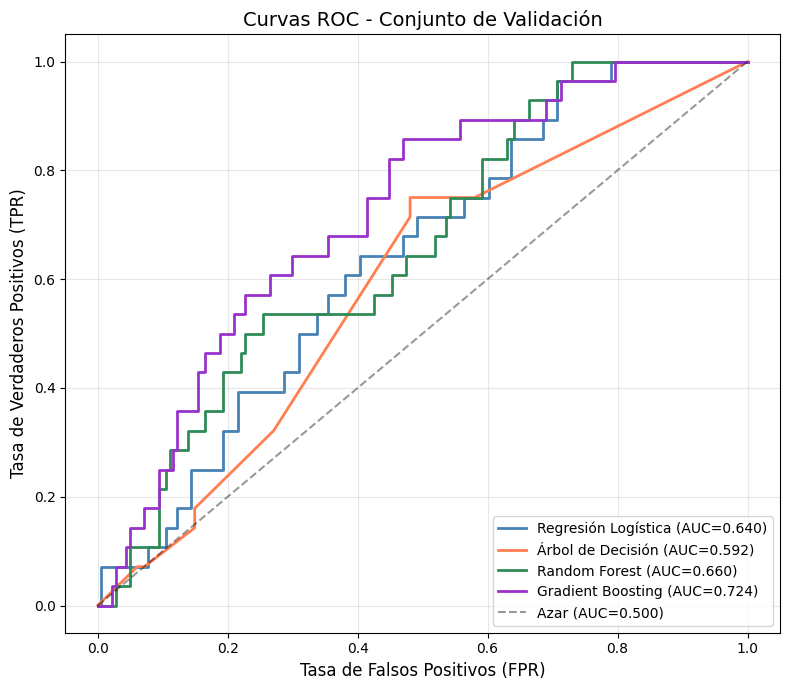


  PASO 16: CURVAS PRECISION-RECALL


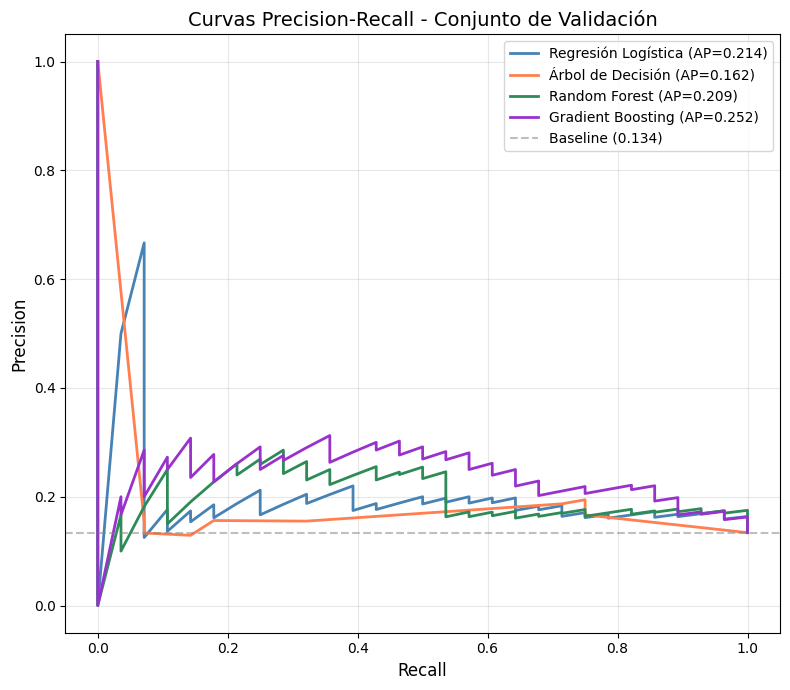


  PASO 17: MATRICES DE CONFUSIÓN (Validación)


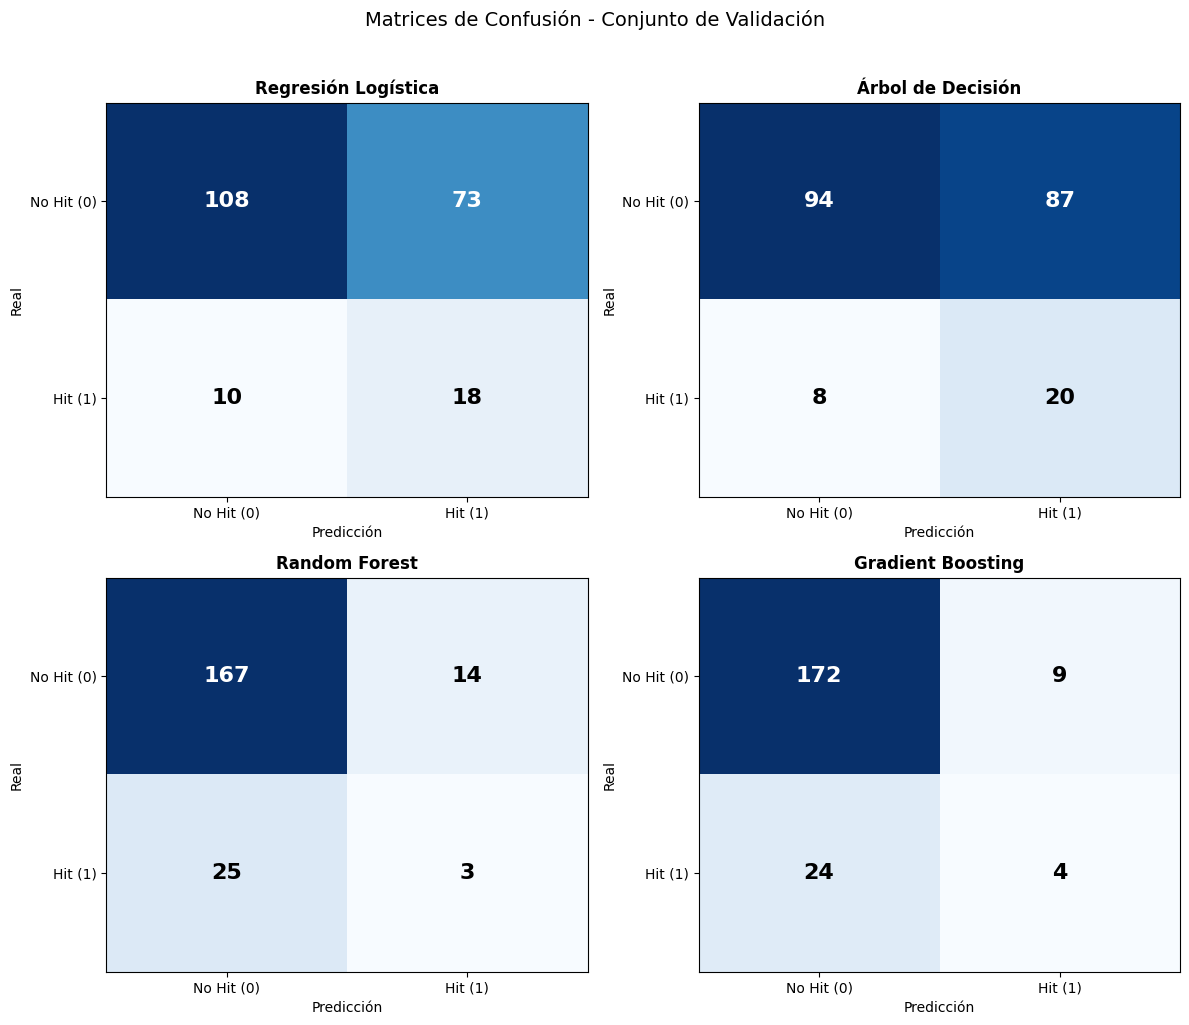


  PASO 18: PRECISION@K

--- Precision@K en Validación ---
Modelo                     P@5    P@10   P@15   P@20   P@25   P@30 
---------------------------------------------------------------------------
Regresión Logística        0.400  0.200  0.133  0.150  0.160  0.167
Árbol de Decisión          0.000  0.100  0.133  0.100  0.080  0.133
Random Forest              0.000  0.100  0.200  0.150  0.240  0.267
Gradient Boosting          0.200  0.200  0.267  0.250  0.280  0.267


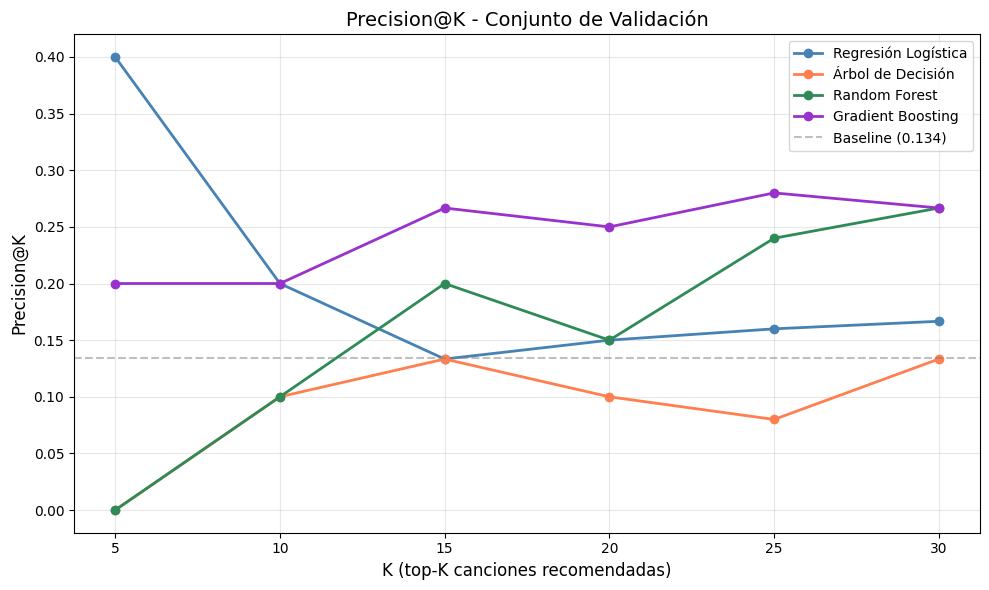


  PASO 19: EVALUACIÓN FINAL EN CONJUNTO DE TEST

Modelo seleccionado: Gradient Boosting
(Seleccionado por mayor ROC-AUC en validación)

--- Métricas en Test (Gradient Boosting) ---
  Accuracy:  0.8565
  Precision: 0.3750
  Recall:    0.1071
  F1-Score:  0.1667
  ROC-AUC:   0.7190

--- Classification Report (Test) ---
              precision    recall  f1-score   support

  No Hit (0)       0.88      0.97      0.92       181
     Hit (1)       0.38      0.11      0.17        28

    accuracy                           0.86       209
   macro avg       0.63      0.54      0.54       209
weighted avg       0.81      0.86      0.82       209



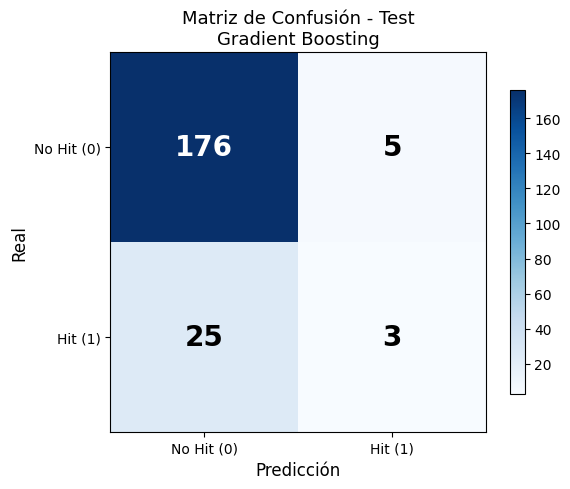

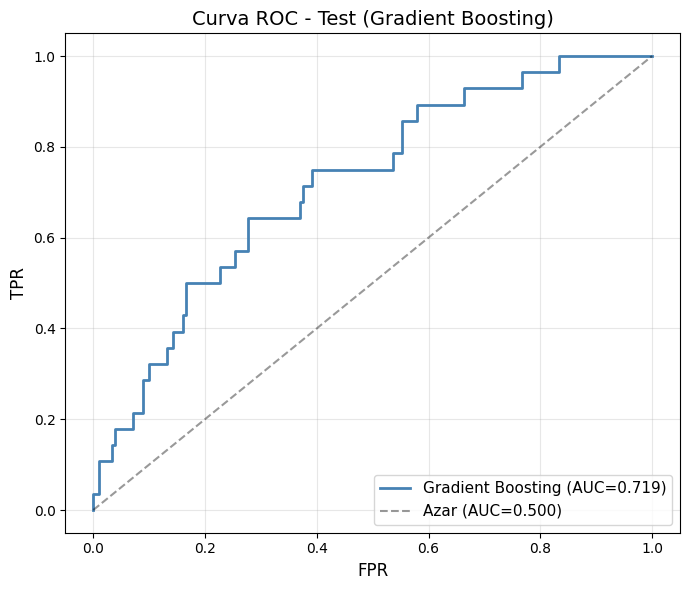


--- Precision@K en Test (Gradient Boosting) ---
  P@ 5: 0.600
  P@10: 0.400
  P@15: 0.333
  P@20: 0.300
  P@25: 0.320
  P@30: 0.300

  PASO 20: TABLA COMPARATIVA FINAL

--- Métricas en VALIDACIÓN ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.6029,0.1978,0.6429,0.3025,0.6397
1,Árbol de Decisión,0.5455,0.1869,0.7143,0.2963,0.5923
2,Random Forest,0.8134,0.1765,0.1071,0.1333,0.6600
3,Gradient Boosting,0.8421,0.3077,0.1429,0.1951,0.7240



--- Métricas en TEST ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.6746,0.2297,0.6071,0.3333,0.7169
1,Árbol de Decisión,0.5694,0.1961,0.7143,0.3077,0.5951
2,Random Forest,0.8660,0.5000,0.1429,0.2222,0.7429
3,Gradient Boosting,0.8565,0.3750,0.1071,0.1667,0.7190


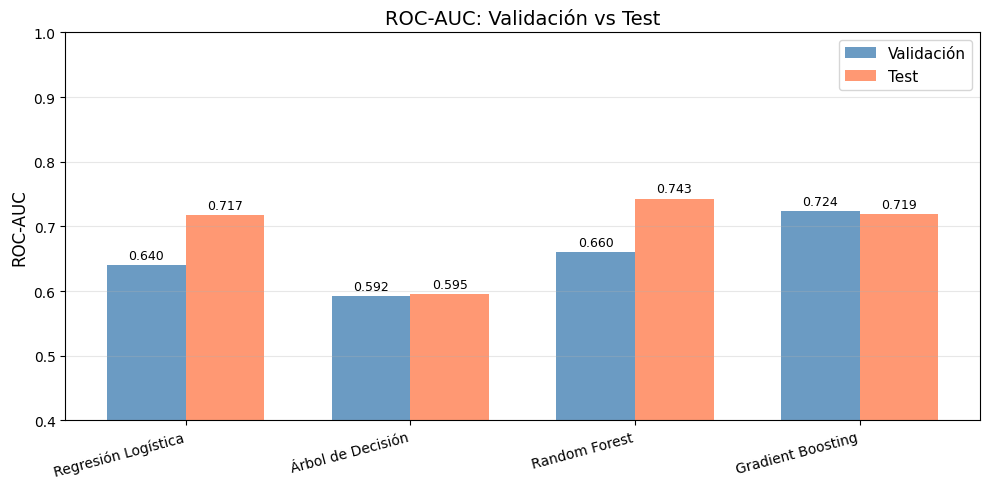


  RESUMEN - CAPÍTULO 12: EVALUACIÓN DE MODELOS

Evaluación sobre conjunto de VALIDACIÓN (209 muestras):



,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.6029,0.1978,0.6429,0.3025,0.6397
1,Árbol de Decisión,0.5455,0.1869,0.7143,0.2963,0.5923
2,Random Forest,0.8134,0.1765,0.1071,0.1333,0.6600
3,Gradient Boosting,0.8421,0.3077,0.1429,0.1951,0.7240



Evaluación sobre conjunto de TEST (209 muestras):



,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.6746,0.2297,0.6071,0.3333,0.7169
1,Árbol de Decisión,0.5694,0.1961,0.7143,0.3077,0.5951
2,Random Forest,0.8660,0.5000,0.1429,0.2222,0.7429
3,Gradient Boosting,0.8565,0.3750,0.1071,0.1667,0.7190



Modelo seleccionado: Gradient Boosting
  - ROC-AUC validación: 0.724
  - ROC-AUC test:       0.7190
  - F1-Score test:      0.1667
  - Precision test:     0.3750
  - Recall test:        0.1071

📌 El análisis detallado de resultados y recomendaciones
   se desarrollará en los Capítulos 13 y 14.



In [2]:

# ============================================================
# PASO 13: Importar métricas de evaluación
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

print("✅ Métricas de evaluación importadas")

# ============================================================
# PASO 14: Evaluación en VALIDACIÓN (para comparar modelos)
# ============================================================

print("\n" + "="*60)
print("  PASO 14: EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
print("="*60)

# Calcular métricas para cada modelo en validación
resultados_val = []

for nombre, modelo in modelos.items():
    # Predicciones
    y_pred = modelo.predict(X_val_scaled)
    y_proba = modelo.predict_proba(X_val_scaled)[:, 1]

    # Métricas
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_proba)

    resultados_val.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

df_val = pd.DataFrame(resultados_val)
print("\n--- Métricas en Validación ---")
display(df_val)

# Identificar mejor modelo por ROC-AUC
mejor_idx = df_val["ROC-AUC"].idxmax()
mejor_nombre = df_val.loc[mejor_idx, "Modelo"]
mejor_auc = df_val.loc[mejor_idx, "ROC-AUC"]
print(f"\n🏆 Mejor modelo por ROC-AUC: {mejor_nombre} ({mejor_auc})")

# ============================================================
# PASO 15: Curvas ROC comparativas (validación)
# ============================================================

print("\n" + "="*60)
print("  PASO 15: CURVAS ROC COMPARATIVAS")
print("="*60)

plt.figure(figsize=(8, 7))

colores = ["steelblue", "coral", "seagreen", "darkorchid"]

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_proba = modelo.predict_proba(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_val = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, color=colores[i], linewidth=2,
             label=f"{nombre} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar (AUC=0.500)")
plt.xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
plt.ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
plt.title("Curvas ROC - Conjunto de Validación", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# PASO 16: Curvas Precision-Recall (validación)
# ============================================================

print("\n" + "="*60)
print("  PASO 16: CURVAS PRECISION-RECALL")
print("="*60)

plt.figure(figsize=(8, 7))

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_proba = modelo.predict_proba(X_val_scaled)[:, 1]
    prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    plt.plot(rec_curve, prec_curve, color=colores[i], linewidth=2,
             label=f"{nombre} (AP={ap:.3f})")

# Línea base = proporción de clase positiva
baseline = y_val.mean()
plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5,
            label=f"Baseline ({baseline:.3f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Curvas Precision-Recall - Conjunto de Validación", fontsize=14)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# PASO 17: Matrices de confusión (validación)
# ============================================================

print("\n" + "="*60)
print("  PASO 17: MATRICES DE CONFUSIÓN (Validación)")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_val_scaled)
    cm = confusion_matrix(y_val, y_pred)

    # Dibujar la matriz manualmente (sin seaborn)
    ax = axes[i]
    im = ax.imshow(cm, cmap="Blues", aspect="auto")

    # Etiquetas de los valores
    for row in range(2):
        for col in range(2):
            valor = cm[row, col]
            color_text = "white" if valor > cm.max() / 2 else "black"
            ax.text(col, row, str(valor), ha="center", va="center",
                    fontsize=16, fontweight="bold", color=color_text)

    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Hit (0)", "Hit (1)"])
    ax.set_yticklabels(["No Hit (0)", "Hit (1)"])
    ax.set_title(nombre, fontsize=12, fontweight="bold")

plt.suptitle("Matrices de Confusión - Conjunto de Validación", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# PASO 18: Precision@K (validación)
# ============================================================

print("\n" + "="*60)
print("  PASO 18: PRECISION@K")
print("="*60)

# Precision@K: de las K canciones con mayor probabilidad predicha,
# ¿cuántas realmente saltaron a Top 200?

K_values = [5, 10, 15, 20, 25, 30]

print("\n--- Precision@K en Validación ---")
print(f"{'Modelo':<25s}", end="")
for k in K_values:
    print(f"  P@{k:<3d}", end="")
print()
print("-" * 75)

precision_at_k_results = []

for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_val_scaled)[:, 1]

    # Ordenar por probabilidad descendente
    idx_sorted = np.argsort(y_proba)[::-1]
    y_true_sorted = y_val.values[idx_sorted]

    row = {"Modelo": nombre}
    print(f"{nombre:<25s}", end="")
    for k in K_values:
        if k <= len(y_true_sorted):
            p_at_k = y_true_sorted[:k].sum() / k
        else:
            p_at_k = 0
        row[f"P@{k}"] = round(p_at_k, 4)
        print(f"  {p_at_k:.3f}", end="")
    print()
    precision_at_k_results.append(row)

df_pk = pd.DataFrame(precision_at_k_results)

# Gráfico de Precision@K
plt.figure(figsize=(10, 6))
for i, (nombre, modelo) in enumerate(modelos.items()):
    y_proba = modelo.predict_proba(X_val_scaled)[:, 1]
    idx_sorted = np.argsort(y_proba)[::-1]
    y_true_sorted = y_val.values[idx_sorted]

    pk_vals = [y_true_sorted[:k].sum() / k for k in K_values]
    plt.plot(K_values, pk_vals, marker="o", color=colores[i],
             linewidth=2, label=nombre)

plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5,
            label=f"Baseline ({baseline:.3f})")
plt.xlabel("K (top-K canciones recomendadas)", fontsize=12)
plt.ylabel("Precision@K", fontsize=12)
plt.title("Precision@K - Conjunto de Validación", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(K_values)
plt.tight_layout()
plt.show()

# ============================================================
# PASO 19: Selección del mejor modelo y evaluación en TEST
# ============================================================

print("\n" + "="*60)
print("  PASO 19: EVALUACIÓN FINAL EN CONJUNTO DE TEST")
print("="*60)

# Seleccionar el mejor modelo identificado en validación
mejor_modelo = modelos[mejor_nombre]
print(f"\nModelo seleccionado: {mejor_nombre}")
print("(Seleccionado por mayor ROC-AUC en validación)")

# Predicciones en test
y_test_pred = mejor_modelo.predict(X_test_scaled)
y_test_proba = mejor_modelo.predict_proba(X_test_scaled)[:, 1]

# Métricas en test
print(f"\n--- Métricas en Test ({mejor_nombre}) ---")
acc_test = accuracy_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred, zero_division=0)
rec_test = recall_score(y_test, y_test_pred, zero_division=0)
f1_test = f1_score(y_test, y_test_pred, zero_division=0)
auc_test = roc_auc_score(y_test, y_test_proba)

print(f"  Accuracy:  {acc_test:.4f}")
print(f"  Precision: {prec_test:.4f}")
print(f"  Recall:    {rec_test:.4f}")
print(f"  F1-Score:  {f1_test:.4f}")
print(f"  ROC-AUC:   {auc_test:.4f}")

# Classification report completo
print(f"\n--- Classification Report (Test) ---")
print(classification_report(y_test, y_test_pred,
                             target_names=["No Hit (0)", "Hit (1)"]))

# Matriz de confusión en test
plt.figure(figsize=(6, 5))
cm_test = confusion_matrix(y_test, y_test_pred)
im = plt.imshow(cm_test, cmap="Blues", aspect="auto")
for row in range(2):
    for col in range(2):
        valor = cm_test[row, col]
        color_text = "white" if valor > cm_test.max() / 2 else "black"
        plt.text(col, row, str(valor), ha="center", va="center",
                fontsize=20, fontweight="bold", color=color_text)
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Real", fontsize=12)
plt.xticks([0, 1], ["No Hit (0)", "Hit (1)"])
plt.yticks([0, 1], ["No Hit (0)", "Hit (1)"])
plt.title(f"Matriz de Confusión - Test\n{mejor_nombre}", fontsize=13)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

# Curva ROC en test
plt.figure(figsize=(7, 6))
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr_test, tpr_test, color="steelblue", linewidth=2,
         label=f"{mejor_nombre} (AUC={auc_test:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar (AUC=0.500)")
plt.xlabel("FPR", fontsize=12)
plt.ylabel("TPR", fontsize=12)
plt.title(f"Curva ROC - Test ({mejor_nombre})", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precision@K en test
print(f"\n--- Precision@K en Test ({mejor_nombre}) ---")
idx_sorted_test = np.argsort(y_test_proba)[::-1]
y_test_sorted = y_test.values[idx_sorted_test]

for k in K_values:
    if k <= len(y_test_sorted):
        p_at_k = y_test_sorted[:k].sum() / k
        print(f"  P@{k:>2d}: {p_at_k:.3f}")

# ============================================================
# PASO 20: Comparativa completa (validación vs test)
# ============================================================

print("\n" + "="*60)
print("  PASO 20: TABLA COMPARATIVA FINAL")
print("="*60)

# Agregar métricas de test para todos los modelos
resultados_test = []
for nombre, modelo in modelos.items():
    yp = modelo.predict(X_test_scaled)
    yprob = modelo.predict_proba(X_test_scaled)[:, 1]
    resultados_test.append({
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_test, yp), 4),
        "Precision": round(precision_score(y_test, yp, zero_division=0), 4),
        "Recall": round(recall_score(y_test, yp, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, yp, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, yprob), 4)
    })

df_test = pd.DataFrame(resultados_test)

print("\n--- Métricas en VALIDACIÓN ---")
display(df_val)

print("\n--- Métricas en TEST ---")
display(df_test)

# Gráfico comparativo de ROC-AUC (validación vs test)
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(modelos))
width = 0.35

bars_val = ax.bar(x_pos - width/2, df_val["ROC-AUC"], width,
                   label="Validación", color="steelblue", alpha=0.8)
bars_test = ax.bar(x_pos + width/2, df_test["ROC-AUC"], width,
                    label="Test", color="coral", alpha=0.8)

# Agregar valores encima de las barras
for bar in bars_val:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("ROC-AUC: Validación vs Test", fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels([n for n in modelos.keys()], rotation=15, ha="right")
ax.legend(fontsize=11)
ax.set_ylim(0.4, 1.0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ============================================================
# RESUMEN FINAL DEL CAPÍTULO 12
# ============================================================

print("\n" + "="*60)
print("  RESUMEN - CAPÍTULO 12: EVALUACIÓN DE MODELOS")
print("="*60)

print(f"""
Evaluación sobre conjunto de VALIDACIÓN (209 muestras):
""")
display(df_val)

print(f"""
Evaluación sobre conjunto de TEST (209 muestras):
""")
display(df_test)

print(f"""
Modelo seleccionado: {mejor_nombre}
  - ROC-AUC validación: {mejor_auc}
  - ROC-AUC test:       {auc_test:.4f}
  - F1-Score test:      {f1_test:.4f}
  - Precision test:     {prec_test:.4f}
  - Recall test:        {rec_test:.4f}

📌 El análisis detallado de resultados y recomendaciones
   se desarrollará en los Capítulos 13 y 14.
""")